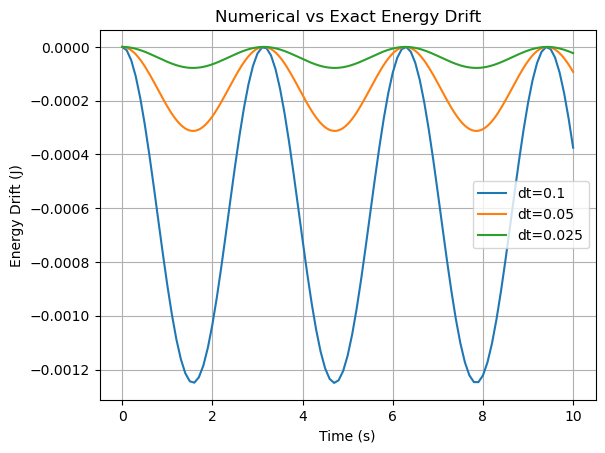

Timestep 0.1s: Max Energy Drift = 0.001250 J
Timestep 0.05s: Max Energy Drift = 0.000312 J
Timestep 0.025s: Max Energy Drift = 0.000078 J


In [10]:
import numpy as np
import matplotlib.pyplot as plt

m = 1.0    
k = 1.0    
omega = np.sqrt(k / m)  
A = 1.0   
dt_values = [0.1, 0.05, 0.025] 
t_max = 10.0 
steps = int(t_max / min(dt_values))  

t = np.linspace(0, t_max, steps + 1)
x_exact = A * np.cos(omega * t) 
v_exact = -A * omega * np.sin(omega * t)  
E_exact = 0.5 * k * x_exact**2 + 0.5 * m * v_exact**2  

results = {}

for dt in dt_values:
    steps_dt = int(t_max / dt)
    t_dt = np.linspace(0, t_max, steps_dt + 1)

    x = [A]
    v = [0.0]
    a = [-k/m * x[0]] 
    
    for i in range(steps_dt):
        x_new = x[-1] + v[-1] * dt + 0.5 * a[-1] * dt**2
        a_new = -k/m * x_new
        v_new = v[-1] + 0.5 * (a[-1] + a_new) * dt
        x.append(x_new)
        v.append(v_new)
        a.append(a_new)
    
    E_num = 0.5 * k * np.array(x)**2 + 0.5 * m * np.array(v)**2 
    E_exact_interp = np.interp(t_dt, t, E_exact) 
    E_drift = np.max(np.abs(E_num - E_exact_interp))
    results[dt] = {'t': t_dt, 'x': x, 'v': v, 'E_num': E_num, 'E_drift': E_drift}

for dt in dt_values:
    plt.plot(results[dt]['t'], results[dt]['E_num'] - np.interp(results[dt]['t'], t, E_exact), label=f'dt={dt}')
plt.xlabel('Time (s)')
plt.ylabel('Energy Drift (J)')
plt.title('Numerical vs Exact Energy Drift')
plt.legend()
plt.grid(True)
plt.show()

for dt, data in results.items():
    print(f"Timestep {dt}s: Max Energy Drift = {data['E_drift']:.6f} J")
